In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100000,
                           n_features=30,
                           n_informative=10,
                           flip_y=0.2)

param_range = np.arange(1, 30)
dt = RandomForestClassifier(random_state=42)

train_score, validation_score = validation_curve(
    dt, X, y, cv=5,
    param_name="max_depth",
    param_range=param_range,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_score.mean(axis=1)
valid_mean = validation_score.mean(axis=1)

plt.plot(param_range, train_mean, label="Training score", color='orange')
plt.plot(param_range, valid_mean, label="validation score", color='blue')

plt.title("Validation curve: max_depth")
plt.xlabel("max_depth")
plt.ylabel("Score: ROC AUC")
plt.legend()
plt.show()

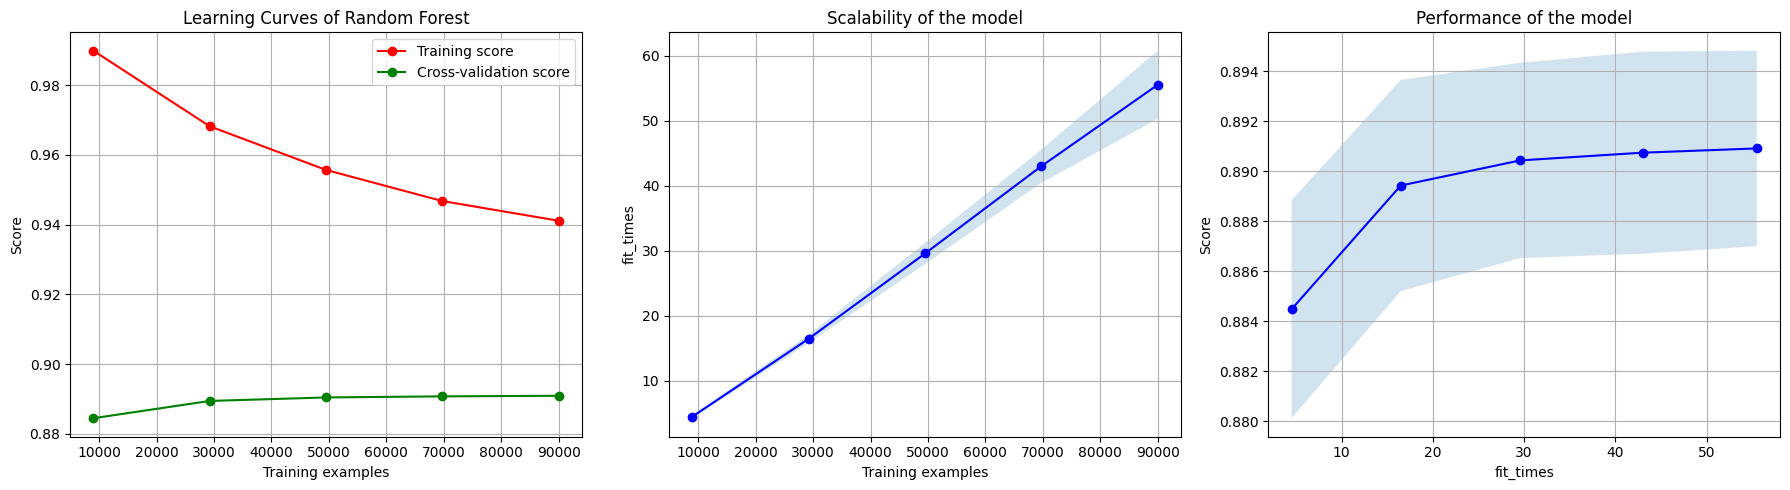

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=10, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator, X, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        scoring='roc_auc',
        return_times=True
    )

    train_mean = train_scores.mean(axis=1)
    test_mean  = test_scores.mean(axis=1)
    test_std   = test_scores.std(axis=1)
    fit_mean   = fit_times.mean(axis=1)
    fit_std    = fit_times.std(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].set_title("Learning Curves of Random Forest")
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")
    axes[0].plot(train_sizes, train_mean, 'o-', color='red',  label="Training score")
    axes[0].plot(train_sizes, test_mean,  'o-', color='green', label="Cross-validation score")
    axes[0].legend()
    axes[0].grid()

    axes[1].set_title("Scalability of the model")
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].plot(train_sizes, fit_mean, 'o-', color='blue')
    axes[1].fill_between(train_sizes, fit_mean - fit_std,
                                      fit_mean + fit_std, alpha=0.2)
    axes[1].grid()

    axes[2].set_title("Performance of the model")
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].plot(fit_mean, test_mean, 'o-', color='blue')
    axes[2].fill_between(fit_mean, test_mean - test_std,
                                   test_mean + test_std, alpha=0.2)
    axes[2].grid()

    plt.tight_layout()
    plt.show()

clf = RandomForestClassifier(max_depth=12, random_state=42)
plot_learning_curve(clf, X, y)
